We start by performing some statistical operation to analyse the dataset, each file contains the average precipitation for a long/lat region on a month of the year. and each was treated by its own.

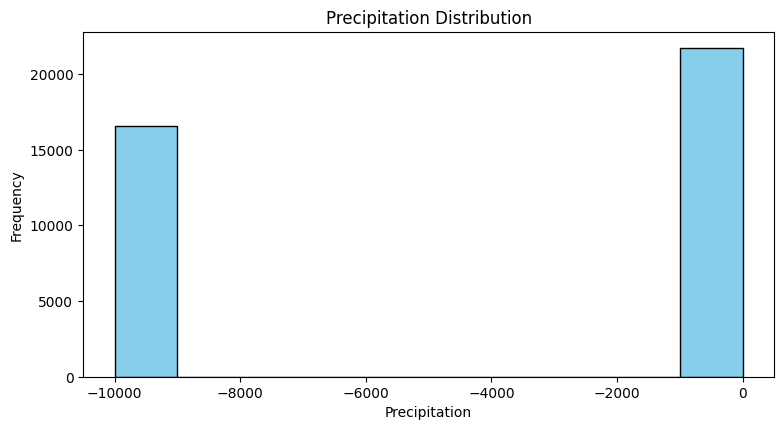

(16554,
            Latitude    Longitude  Precipitation
 count  38247.000000  38247.00000   38247.000000
 mean      28.050000      1.65000   -4328.135478
 std        5.282745      6.03332    4954.679155
 min       18.949999     -8.75000   -9999.900000
 25%       23.449999     -3.55000   -9999.900000
 50%       28.050000      1.65000       0.000895
 75%       32.649998      6.85000       0.003105
 max       37.149998     12.05000       0.102368)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('Dataset_01_2023.csv')


fill_value_count = (df["Precipitation"] == -9999.9).sum()


basic_stats = df.describe()


plt.figure(figsize=(15, 8))


plt.subplot(2, 2, 1)
plt.hist(df["Precipitation"], bins=10, color='skyblue', edgecolor='black')
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")



plt.tight_layout()
plt.show()


fill_value_count, basic_stats


As you can see, the number of instances filled with the fill value [-9999.9] is 16554 over 38248. Non of them could be removed; otherwhise, we will not cover all of Algeria, so they have to be filled with some logical values, and how can this be done:

We have used the Nearest_Neighbors Interpolation, it wich for each data point, we see the nearest valid points and assign it a valid precision rate.

Here each file was handled alone because the data of one montrh is not likely to be mixed with other monthes.


In [7]:
import numpy as np
import pandas as pd
from scipy.interpolate import griddata


input_csv_path = 'Dataset_01_2023.csv'
df = pd.read_csv(input_csv_path)

df['Precipitation'] = df['Precipitation'].replace(-9999.9, np.nan)

latitudes = df['Latitude'].values
longitudes = df['Longitude'].values
precipitation = df['Precipitation'].values

valid_mask = ~np.isnan(precipitation)


valid_latitudes = latitudes[valid_mask]
valid_longitudes = longitudes[valid_mask]
valid_precipitation = precipitation[valid_mask]


lat_bin_size = 0.1
lon_bin_size = 0.1
lat_bins = np.arange(latitudes.min(), latitudes.max() + lat_bin_size, lat_bin_size)
lon_bins = np.arange(longitudes.min(), longitudes.max() + lon_bin_size, lon_bin_size)
latitude_grid, longitude_grid = np.meshgrid(lat_bins, lon_bins)


interpolated_precipitation = griddata(
    (valid_longitudes, valid_latitudes),
    valid_precipitation,
    (longitude_grid.flatten(), latitude_grid.flatten()),
    method='nearest'
)


interpolated_precipitation = interpolated_precipitation.reshape(latitude_grid.shape)


def interpolate_precipitation(row):
    if np.isnan(row['Precipitation']):
        lat_idx = np.abs(lat_bins - row['Latitude']).argmin()
        lon_idx = np.abs(lon_bins - row['Longitude']).argmin()
        return interpolated_precipitation[lon_idx, lat_idx]
    else:
        return row['Precipitation']


df['Final_Precipitation'] = df.apply(interpolate_precipitation, axis=1)


final_df = df[['Latitude', 'Longitude', 'Final_Precipitation']]


final_df = final_df.rename(columns={'Final_Precipitation': 'Precipitation'})


output_csv_path = 'cleaned_01_2023.csv'
final_df.to_csv(output_csv_path, index=False)

print(f"Cleaned CSV file saved as {output_csv_path}")


Cleaned CSV file saved as cleaned_01_2023.csv


Now we will try to detect and handle the outliers on each file, but we can not look for the outliers on the whole algeria, because it makes sense that the precipitation rate on the south is different from that in the north, so we can not consider them in the same context.

As a result, we splitted Algeria into 837 circles with the raduis 0.5, in which the datapints inside will be compared to each other to define the outliers.

The outliers then will be handled the same way the missing values were handled.

In [8]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.interpolate import griddata, NearestNDInterpolator

def create_circle_centers(lat_min=18.95, lat_max=37.15, lon_min=-8.75, lon_max=12.05, radius=0.5):

    step_size = radius * np.sqrt(2)
    lats = np.arange(lat_min, lat_max + step_size, step_size)
    lons = np.arange(lon_min, lon_max + step_size, step_size)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    centers = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
    return centers

def interpolate_values(valid_points, valid_values, outlier_points):

    try:
        interpolator = NearestNDInterpolator(valid_points, valid_values)
        interpolated = interpolator(outlier_points)

        try:
            linear_interp = griddata(
                valid_points,
                valid_values,
                outlier_points,
                method='linear'
            )
            valid_linear = ~np.isnan(linear_interp)
            interpolated[valid_linear] = linear_interp[valid_linear]
        except Exception:
            pass

        return interpolated
    except Exception as e:
        print(f"Interpolation failed: {str(e)}")

        return np.full(len(outlier_points), np.mean(valid_values))

def detect_and_handle_outliers_in_circle(points, values, center, radius):

    distances = cdist([center], points)[0]

    circle_mask = distances <= radius
    circle_values = values[circle_mask]
    circle_points = points[circle_mask]

    if len(circle_values) < 4:
        return values.copy(), np.zeros_like(values, dtype=bool)

    Q1 = np.percentile(circle_values, 25)
    Q3 = np.percentile(circle_values, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    circle_outlier_mask = (circle_values < lower_bound) | (circle_values > upper_bound)

    outlier_mask = np.zeros_like(values, dtype=bool)
    outlier_mask[circle_mask] = circle_outlier_mask

    handled_values = values.copy()
    if circle_outlier_mask.any():
        valid_circle_points = circle_points[~circle_outlier_mask]
        valid_circle_values = circle_values[~circle_outlier_mask]
        outlier_points = circle_points[circle_outlier_mask]

        if len(valid_circle_points) >= 3:
            interpolated_values = interpolate_values(
                valid_circle_points,
                valid_circle_values,
                outlier_points
            )

            outlier_indices = np.where(circle_mask)[0][circle_outlier_mask]
            handled_values[outlier_indices] = interpolated_values

    return handled_values, outlier_mask

def process_precipitation_data(df, radius=0.5):

    points = df[['Latitude', 'Longitude']].values
    values = df['Precipitation'].values

    centers = create_circle_centers(radius=radius)
    num_circles = len(centers)
    print(f"Analysis will be performed using {num_circles} circles with radius {radius}°")

    handled_values = values.copy()
    all_outliers = np.zeros_like(values, dtype=bool)
    circles_with_outliers = 0
    total_outliers = 0

    for i, center in enumerate(centers, 1):
        if i % 100 == 0:
            print(f"Processing circle {i}/{num_circles}")

        handled_values, outlier_mask = detect_and_handle_outliers_in_circle(
            points, handled_values, center, radius
        )

        if outlier_mask.any():
            circles_with_outliers += 1
            total_outliers += outlier_mask.sum()
            all_outliers = all_outliers | outlier_mask

    points_per_circle = [
        np.sum(cdist([center], points)[0] <= radius) for center in centers
    ]
    avg_points_per_circle = np.mean(points_per_circle)

    print(f"\nAnalysis Summary:")
    print(f"Total circles: {num_circles}")
    print(f"Circles containing outliers: {circles_with_outliers}")
    print(f"Average points per circle: {avg_points_per_circle:.1f}")
    print(f"Total outliers detected and handled: {total_outliers}")
    print(f"Percentage of data points handled: {(total_outliers / len(values)) * 100:.1f}%")

    df_cleaned = df.copy()
    df_cleaned['Precipitation_Cleaned'] = handled_values
    df_cleaned['IsOutlier'] = all_outliers
    df_cleaned['Original_Precipitation'] = df['Precipitation']

    return df_cleaned

def main():
    input_file = 'cleaned_01_2023.csv'
    df = pd.read_csv(input_file)

    radius = 0.5
    print(f"\nProcessing with circle radius: {radius}°")
    df_cleaned = process_precipitation_data(df, radius=radius)

    output_file = 'preprocessed_01_2023.csv'
    df_cleaned.to_csv(output_file, index=False)
    print(f"Saved results to {output_file}")

if __name__ == "__main__":
    main()



Processing with circle radius: 0.5°
Analysis will be performed using 837 circles with radius 0.5°
Processing circle 100/837
Processing circle 200/837
Processing circle 300/837
Processing circle 400/837
Processing circle 500/837
Processing circle 600/837
Processing circle 700/837
Processing circle 800/837

Analysis Summary:
Total circles: 837
Circles containing outliers: 304
Average points per circle: 71.8
Total outliers detected and handled: 2147
Percentage of data points handled: 5.6%
Saved results to preprocessed_01_2023.csv


We do repeat the same statistics as in the first.

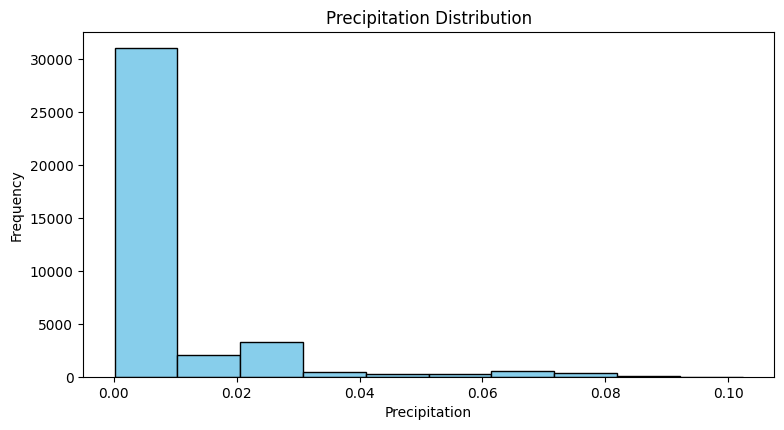

(0,
            Latitude    Longitude  Precipitation  Precipitation_Cleaned  \
 count  38247.000000  38247.00000   38247.000000           38247.000000   
 mean      28.050000      1.65000       0.008349               0.008385   
 std        5.282745      6.03332       0.014075               0.014182   
 min       18.949999     -8.75000       0.000105               0.000105   
 25%       23.449999     -3.55000       0.001421               0.001421   
 50%       28.050000      1.65000       0.003053               0.003053   
 75%       32.649998      6.85000       0.007421               0.007421   
 max       37.149998     12.05000       0.102368               0.102368   
 
        Original_Precipitation  
 count            38247.000000  
 mean                 0.008349  
 std                  0.014075  
 min                  0.000105  
 25%                  0.001421  
 50%                  0.003053  
 75%                  0.007421  
 max                  0.102368  )

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('preprocessed_01_2023.csv')


fill_value_count = (df["Precipitation"] == -9999.9).sum()


basic_stats = df.describe()


plt.figure(figsize=(15, 8))


plt.subplot(2, 2, 1)
plt.hist(df["Precipitation"], bins=10, color='skyblue', edgecolor='black')
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")



plt.tight_layout()
plt.show()


fill_value_count, basic_stats


Now after the data was handled correctly, we will stick the files of the whole year (1_12) 2023/2022 each together, In order to build both the training set (2023) and the testing set (2022).

When sticking we will add the new attributes, season (winter, summer...) and month (x_month, y_year), So we can later on avoid easely the data lickage.

In [ ]:
import pandas as pd
import glob
import os
from datetime import datetime

def combine_weather_data(directory_path):
    try:
        files = glob.glob(os.path.join(directory_path, "preprocessed_*_2023.csv"))

        if not files:
            raise FileNotFoundError(f"No preprocessed files found in {directory_path}")

        print(f"Found {len(files)} files to process")

        dfs = []

        for file in files:
            try:

                month = int(file.split('preprocessed_')[1].split('_')[0])

                df = pd.read_csv(file)

                required_columns = ['Latitude', 'Longitude', 'Precipitation_Cleaned']
                missing_columns = [col for col in required_columns if col not in df.columns]
                if missing_columns:
                    raise ValueError(f"Missing required columns in {file}: {missing_columns}")

                df = df[required_columns]

                df['month'] = f"{month}_2022"

                if month in [12, 1, 2]:
                    df['season'] = 'winter'
                elif month in [3, 4, 5]:
                    df['season'] = 'spring'
                elif month in [6, 7, 8]:
                    df['season'] = 'summer'
                else:
                    df['season'] = 'autumn'

                print(f"Processed file for month {month}: {df.shape[0]} rows")
                dfs.append(df)

            except Exception as e:
                print(f"Error processing file {file}: {str(e)}")
                continue

        if not dfs:
            raise ValueError("No data was successfully processed")

        combined_df = pd.concat(dfs, ignore_index=True)

        month_order = {f"{i}_2022": i for i in range(1, 13)}
        combined_df['month_num'] = combined_df['month'].map(month_order)
        combined_df = combined_df.sort_values('month_num').drop('month_num', axis=1)

        combined_df = combined_df[['season', 'month', 'Longitude', 'Latitude', 'Precipitation_Cleaned']]

        print("\nData Processing Summary:")
        print(f"Total rows in combined dataset: {combined_df.shape[0]}")
        print(f"Number of unique months: {combined_df['month'].nunique()}")
        print(f"Number of unique seasons: {combined_df['season'].nunique()}")

        return combined_df

    except Exception as e:
        print(f"Error in combine_weather_data: {str(e)}")
        raise

def main():
    directory_path = 'PreProcessedData\Cleaned_CsvFormat_data/'

    try:
        print(f"Starting data processing at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        combined_data = combine_weather_data(directory_path)

        output_file = 'Data_for_classification\Test_Data/New_Test_DataSet.csv'
        combined_data.to_csv(output_file, index=False)
        print(f"\nData successfully saved to {output_file}")

        print("\nSample of combined data:")
        print(combined_data.head())

        print("\nBasic statistics for Precipitation_Cleaned:")
        print(combined_data['Precipitation_Cleaned'].describe())

    except Exception as e:
        print(f"Error in main function: {str(e)}")

if __name__ == "__main__":
    main()

The steps above was repeated for all files, and then all of each year was sicked toghether, so we can get the Tain set: **DataSet.csv** (2023) and the test set: **Test_DataSet.csv** (2022).